In [ ]:
%pip install torch torchvision
%pip install fastai

In [1]:
from fastai.vision.all import *

# **Download the dataset**

In [2]:
path = untar_data(URLs.PETS) / "images"

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 02:16&lt;00:00]</div>

# **Prepare the data**

In [3]:
dls = ImageDataLoaders.from_name_func(
    path,
    get_image_files(path),
    valid_pct=0.2,
    seed=42,
    label_func=lambda x: x[0].isupper(),
    item_tfms=Resize(224)
)

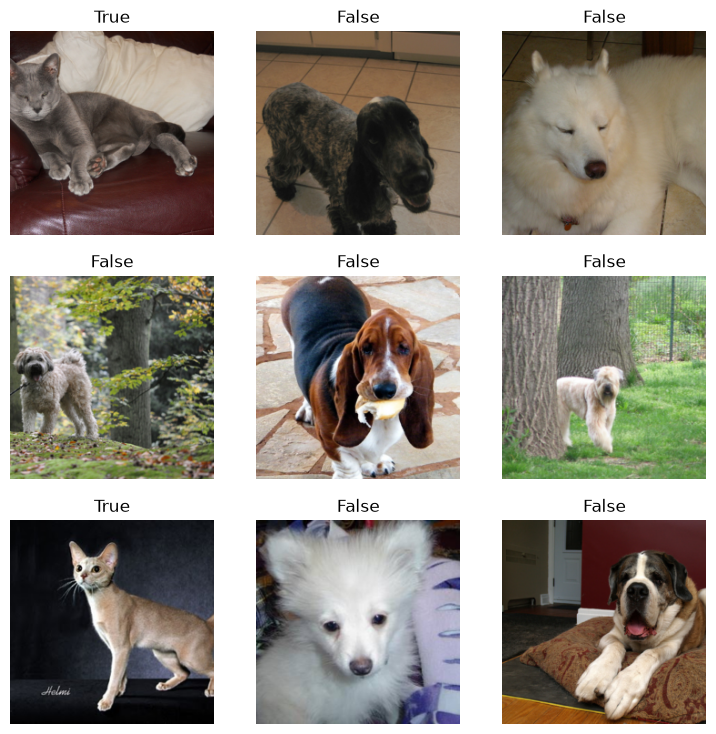

In [5]:
dls.show_batch(nrows=3, ncols=3)

# **Create the model**

In [6]:
learn = vision_learner(
    dls,
    resnet34,
    metrics=error_rate
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/sergiolopezortiz/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:06<00:00, 14.1MB/s]


# **Train the model**

In [7]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.145430,0.030066,0.008796,01:00


epoch,train_loss,valid_loss,error_rate,time
0,0.077296,0.015297,0.002706,01:22


# **Make a prediction**

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

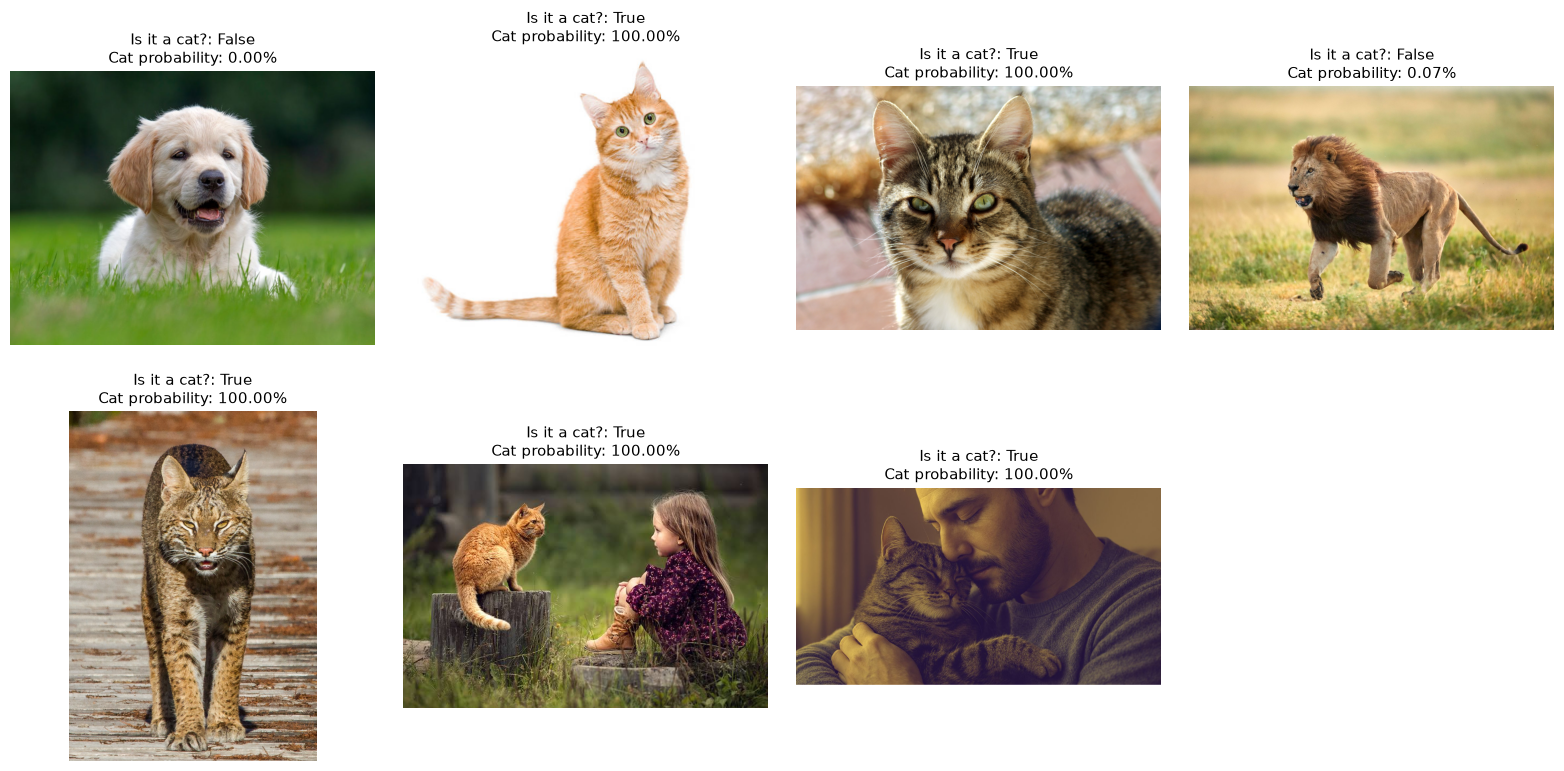

In [26]:
import matplotlib.pyplot as plt
from fastai.vision.all import PILImage
import math

images_array_test = [
    'dog2_test.jpg',
    'cat2_test.jpg',
    'cat1_test.jpg',
    'leon.jpg',
    'gato_montes.jpg',
    'gato_y_humano.jpeg',
    'gato_y_huamano_2.jpg'
]


cols = 4

rows = math.ceil(len(images_array_test) / cols)


fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 8)
)


axes = axes.flatten()

for i, image_path in enumerate(images_array_test):
    img = PILImage.create("test_data/" + image_path)
    is_cat, _, probs = learn.predict(img)
    cat_probability = probs[1].item()
    not_cat_probability = probs[0].item()
    axes[i].imshow(img)
    axes[i].axis('off')

    axes[i].set_title(
        f"Is it a cat?: {is_cat}\n"
        f"Cat probability: {cat_probability:.2%}",
        fontsize=11
    )

for i in range(len(images_array_test), len(axes)):
    axes[i].axis('off')

plt.tight_layout(pad=2)

plt.show()